<a href="https://colab.research.google.com/github/Isadora220825/MVP-Seguran-a-de-Rede/blob/main/mvp_seguran_a_de_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Padrões de Incidentes de Segurança de Rede
### Pipeline de dados em nuvem — versão Google Colab + BigQuery
**Aluna:** Isadora Messenberg / 231013387
**Disciplina:** Engenharia de Produção / UnB — Prof. André Luiz Marques Serrano
**Plataforma de nuvem escolhida:** Google BigQuery (Google Cloud), acessado a partir do Google Colab.
*(O enunciado permite qualquer plataforma além do Databricks — aqui usamos BigQuery como Data Warehouse na nuvem.)*

## Objetivo
Times de segurança recebem um grande volume de eventos de firewalls, IDS/IPS e servidores.
Este pipeline organiza esses eventos em um **modelo dimensional (Esquema Estrela)** persistido
no BigQuery, para responder perguntas que ajudam a priorizar a resposta a incidentes.

## Perguntas de negócio
1. Quais tipos de ataque são mais frequentes e como evoluíram mês a mês (2020–2023)?
2. Existe associação entre protocolo de rede e tipo de ataque?
3. A severidade está associada ao segmento de rede ou ao tipo de ataque?
4. A ação tomada (bloqueado/registrado/ignorado) varia conforme o tipo de ataque?
5. O Anomaly Score é maior para incidentes de severidade alta?
6. Existe concentração geográfica de algum tipo de ataque?

## Base de dados
Fonte: *Cyber Security Attacks* (Incribo, via Kaggle) — **conjunto sintético**, 40.000 linhas, 25 colunas,
licença MIT (confirme na página do Kaggle antes de entregar). `User Information` é anonimizado
(hash SHA-256) antes de qualquer persistência, por precaução com a LGPD.


## 0. Configuração do ambiente

Antes de rodar: crie um projeto gratuito em [console.cloud.google.com](https://console.cloud.google.com/)
(não precisa cartão de crédito para o uso do BigQuery dentro da cota gratuita) e copie o **ID do projeto**
para a variável `PROJECT_ID` na célula abaixo.


In [ ]:
# Instala a biblioteca oficial do Google Cloud para BigQuery (o Colab já traz quase tudo,
# mas garantimos a versão mais recente com --upgrade)
!pip install --quiet --upgrade google-cloud-bigquery


In [ ]:
from google.colab import auth  # módulo do Colab que abre o fluxo de login com sua conta Google
auth.authenticate_user()          # abre um pop-up: faça login e autorize o acesso ao Google Cloud

# Substitua pelo ID do SEU projeto no Google Cloud (não é o nome, é o "Project ID" mostrado no console)
PROJECT_ID = 'mvp-seguranca-redes'

from google.cloud import bigquery                 # cliente oficial para falar com o BigQuery
client = bigquery.Client(project=PROJECT_ID)       # cria a conexão autenticada com o seu projeto
print("Conectado ao projeto:", client.project)     # confirma qual projeto está sendo usado


Conectado ao projeto: mvp-seguranca-redes


In [ ]:
import pandas as pd       # manipulação de tabelas (substitui o PySpark do Databricks)
import numpy as np        # operações numéricas (usado para gerar o id_linha sequencial)
import hashlib             # para gerar o hash SHA-256 usado na anonimização (LGPD)
import re                  # expressões regulares, usadas para interpretar o User-Agent
from datetime import date  # para registrar a data em que a coleta foi feita
from scipy import stats    # testes estatísticos (qui-quadrado e ANOVA) usados na análise de negócio
import matplotlib.pyplot as plt  # gráficos


## 1. Busca e coleta

Faça upload do arquivo `cybersecurity_attacks.csv` (baixado do Kaggle) quando o botão aparecer
na célula abaixo.


In [ ]:
from google.colab import files   # ferramenta do Colab para receber arquivo do seu computador
import io                        # para ler os bytes recebidos como se fossem um arquivo

uploaded = files.upload()  # abre a janela de seleção de arquivo — escolha o cybersecurity_attacks.csv

nome_arquivo = list(uploaded.keys())[0]  # pega o nome do arquivo que você acabou de enviar
DATA_COLETA = date.today().isoformat()   # registra a data de hoje como data efetiva da coleta

# Lê o CSV direto da memória (sem precisar salvar em disco), já convertendo Timestamp para data/hora
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]), parse_dates=["Timestamp"])

print("Data de coleta registrada:", DATA_COLETA)
print("Linhas carregadas:", len(df))         # deve mostrar 40000
print("Colunas carregadas:", len(df.columns))  # deve mostrar 25
df.head(3)  # mostra as 3 primeiras linhas para conferência visual


Saving cybersecurity_attacks.csv to cybersecurity_attacks (1).csv
Data de coleta registrada: 2026-09-28
Linhas carregadas: 40000
Colunas carregadas: 25


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Action Taken,Severity Level,User Information,Device Information,Network Segment,Geo-location Data,Proxy Information,Firewall Logs,IDS/IPS Alerts,Log Source
0,2023-05-30 06:33:58,103.216.15.12,84.9.164.252,31225,17616,ICMP,503,Data,HTTP,Qui natus odio asperiores nam. Optio nobis ius...,...,Logged,Low,Reyansh Dugal,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment A,"Jamshedpur, Sikkim",150.9.97.135,Log Data,NaN,Server
1,2020-08-26 07:08:30,78.199.217.198,66.191.137.154,17245,48166,ICMP,1174,Data,HTTP,Aperiam quos modi officiis veritatis rem. Omni...,...,Blocked,Low,Sumer Rana,Mozilla/5.0 (compatible; MSIE 8.0; Windows NT ...,Segment B,"Bilaspur, Nagaland",NaN,Log Data,NaN,Firewall
2,2022-11-13 08:23:25,63.79.210.48,198.219.82.17,16811,53600,UDP,306,Control,HTTP,Perferendis sapiente vitae soluta. Hic delectu...,...,Ignored,Low,Himmat Karpe,Mozilla/5.0 (compatible; MSIE 9.0; Windows NT ...,Segment C,"Bokaro, Rajasthan",114.133.48.179,Log Data,Alert Data,Firewall


## 2. Persistência da camada *bronze* (dado bruto) no BigQuery

A camada bronze guarda os dados exatamente como recebidos — isso garante que, se algo der errado
na transformação, dá para recomeçar a partir daqui sem precisar reenviar o CSV.


In [ ]:
DATASET_BRONZE = "bronze_cyberseg"  # nome do "banco" (dataset) que vai guardar a tabela bruta

# Cria o dataset no BigQuery caso ele ainda não exista (exists_ok evita erro se já existir)
client.create_dataset(f"{PROJECT_ID}.{DATASET_BRONZE}", exists_ok=True)

df_bronze = df.copy()                         # copia o dataframe para não alterar o original
# BigQuery não aceita "/" nem outros caracteres especiais em nome de coluna — então trocamos por "_"
def sanitizar_nome_coluna(nome):
    nome = re.sub(r"[^0-9a-zA-Z_]", "_", nome.strip())  # troca qualquer caractere inválido por "_"
    return re.sub(r"_+", "_", nome)                      # colapsa underscores repetidos

df_bronze.columns = [sanitizar_nome_coluna(c) for c in df_bronze.columns]  # aplica em todas as colunas

tabela_bronze = f"{PROJECT_ID}.{DATASET_BRONZE}.eventos_seguranca_raw"  # id completo da tabela

# Envia o dataframe inteiro para uma tabela nova no BigQuery, substituindo se já existir
job = client.load_table_from_dataframe(
    df_bronze,
    tabela_bronze,
    job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"),
)
job.result()  # espera o job de carga terminar antes de continuar

print(f"Tabela {tabela_bronze} persistida com {job.output_rows} linhas.")
print("Capture aqui um screenshot do BigQuery Console mostrando essa tabela para /evidencias.")


Tabela mvp-seguranca-redes.bronze_cyberseg.eventos_seguranca_raw persistida com 40000 linhas.
Capture aqui um screenshot do BigQuery Console mostrando essa tabela para /evidencias.


## 3. Modelagem — transformações e regras de negócio aplicadas

1. `Geo-location Data` ("Cidade, Estado") é quebrado em `cidade` e `estado` (atributos atômicos).
2. `Device Information` (user-agent) é interpretado em `navegador` e `sistema_operacional`.
3. `Timestamp` é decomposto em `ano`, `trimestre`, `mes`, `dia`, `hora`, `dia_semana`.
4. Os cinco atributos com ~50% de nulos viram booleanos explícitos (nulo = indicador ausente).
5. `User Information` é anonimizado via hash SHA-256 (LGPD) antes de qualquer persistência.
6. `Payload Data` não é persistido por inteiro — vira `tamanho_payload` e `possui_payload`.


In [ ]:
# ----- Regra 1: geo-localização -----
geo = df["Geo-location Data"].str.split(",", n=1, expand=True)  # separa "Cidade, Estado" em 2 colunas
df["cidade"] = geo[0].str.strip()   # remove espaços em branco da cidade
df["estado"] = geo[1].str.strip()   # remove espaços em branco do estado

# ----- Regra 2: user-agent -> navegador / sistema operacional -----
def parse_navegador(ua):
    # Verifica padrões conhecidos de navegador dentro da string de User-Agent, em ordem de prioridade
    if re.search(r"Firefox", ua, re.I): return "Firefox"
    if re.search(r"MSIE|Trident", ua, re.I): return "Internet Explorer"
    if re.search(r"Edg/", ua, re.I): return "Edge"
    if re.search(r"OPR/|Opera", ua, re.I): return "Opera"
    if re.search(r"Chrome", ua, re.I): return "Chrome"
    if re.search(r"Safari", ua, re.I): return "Safari"
    return "Outro/Não identificado"  # nenhum padrão bateu

def parse_sistema_operacional(ua):
    # Mesma lógica, mas procurando padrões de sistema operacional
    if re.search(r"Windows NT 10", ua, re.I): return "Windows 10/11"
    if re.search(r"Windows NT 6", ua, re.I): return "Windows Vista/7/8"
    if re.search(r"Windows", ua, re.I): return "Windows (outra versão)"
    if re.search(r"Mac OS X", ua, re.I): return "macOS"
    if re.search(r"Linux", ua, re.I): return "Linux"
    if re.search(r"Android", ua, re.I): return "Android"
    if re.search(r"iPhone|iPad", ua, re.I): return "iOS"
    return "Outro/Não identificado"

df["navegador"] = df["Device Information"].apply(parse_navegador)              # aplica a função linha a linha
df["sistema_operacional"] = df["Device Information"].apply(parse_sistema_operacional)

# ----- Regra 3: dim_tempo -----
df["data"] = df["Timestamp"].dt.date            # só a data (sem hora)
df["ano"] = df["Timestamp"].dt.year             # ano numérico
df["trimestre"] = df["Timestamp"].dt.quarter    # trimestre (1 a 4)
df["mes"] = df["Timestamp"].dt.month            # mês (1 a 12)
df["dia"] = df["Timestamp"].dt.day              # dia do mês
df["hora"] = df["Timestamp"].dt.hour            # hora (0 a 23)
df["dia_semana"] = df["Timestamp"].dt.dayofweek + 1  # dia da semana (1=segunda ... 7=domingo)

# ----- Regra 4: indicadores binários (nulo -> False, valor presente -> True) -----
df["possui_indicador_malware"] = df["Malware Indicators"].notna()
df["houve_alerta_disparado"] = df["Alerts/Warnings"].notna()
df["possui_log_firewall"] = df["Firewall Logs"].notna()
df["possui_alerta_ids_ips"] = df["IDS/IPS Alerts"].notna()
df["trafego_via_proxy"] = df["Proxy Information"].notna()

# ----- Regra 5: anonimização de PII (LGPD) -----
# sha256 gera um "hash" irreversível: o mesmo nome sempre gera o mesmo código,
# então dá pra contar/agrupar por usuário sem guardar o nome real.
df["usuario_hash"] = df["User Information"].apply(
    lambda nome: hashlib.sha256(str(nome).encode()).hexdigest()
)

# ----- Regra 6: payload -----
df["tamanho_payload"] = df["Payload Data"].str.len()   # quantidade de caracteres do texto original
df["possui_payload"] = df["Payload Data"].notna()       # se havia payload registrado

print("Transformações aplicadas. Total de linhas:", len(df))
df[["cidade", "estado", "navegador", "usuario_hash"]].head(3)  # conferência visual


Transformações aplicadas. Total de linhas: 40000


,cidade,estado,navegador,usuario_hash
0,Jamshedpur,Sikkim,Internet Explorer,0f1d995919c5d8e8545e5457c5e687a41811dbf0871b10...
1,Bilaspur,Nagaland,Internet Explorer,bb4ae01c7aa10c7bbda4a99d88076d0854b9028799986b...
2,Bokaro,Rajasthan,Internet Explorer,991089ff59a9785d325def76bb0bdb2e247e6cc1eed753...


## 4. Construção das dimensões (Esquema Estrela)

Cada dimensão é a lista de combinações **únicas** de alguns atributos, com uma chave substituta
(`id_*`) sequencial. Detalhes de domínio e linhagem completos em `/catalogo/catalogo_de_dados.md`.


In [ ]:
def construir_dimensao(df, colunas, nome_id):
    # Remove duplicatas pelas colunas informadas e cria uma chave substituta sequencial (1, 2, 3...)
    dim = df[colunas].drop_duplicates().sort_values(colunas).reset_index(drop=True)  # linhas únicas, ordenadas
    dim[nome_id] = dim.index + 1  # gera a chave substituta (começando em 1)
    return dim

# Cada chamada abaixo cria uma dimensão a partir das colunas relevantes do dataframe transformado
dim_tempo = construir_dimensao(
    df, ["data", "ano", "trimestre", "mes", "dia", "hora", "dia_semana"], "id_tempo"
)

dim_protocolo_trafego = construir_dimensao(
    df, ["Protocol", "Packet Type", "Traffic Type"], "id_protocolo_trafego"
).rename(columns={  # renomeia para os nomes finais em português definidos no catálogo
    "Protocol": "protocolo", "Packet Type": "tipo_pacote", "Traffic Type": "tipo_trafego"
})

dim_ataque = construir_dimensao(
    df,
    ["Attack Type", "Attack Signature", "Severity Level", "possui_indicador_malware", "houve_alerta_disparado"],
    "id_ataque",
).rename(columns={
    "Attack Type": "tipo_ataque", "Attack Signature": "assinatura_ataque", "Severity Level": "nivel_severidade"
})

dim_resposta = construir_dimensao(
    df, ["Action Taken", "possui_log_firewall", "possui_alerta_ids_ips", "trafego_via_proxy"], "id_resposta"
).rename(columns={"Action Taken": "acao_tomada"})

dim_geografia = construir_dimensao(df, ["cidade", "estado"], "id_geografia")
dim_geografia["pais"] = "Índia"  # constante: domínio observado nos dados (dataset sintético)

dim_dispositivo = construir_dimensao(df, ["navegador", "sistema_operacional"], "id_dispositivo")

dim_segmento_rede = construir_dimensao(
    df, ["Network Segment"], "id_segmento_rede"
).rename(columns={"Network Segment": "segmento"})

dim_log_source = construir_dimensao(
    df, ["Log Source"], "id_log_source"
).rename(columns={"Log Source": "origem_log"})

# Imprime quantas linhas cada dimensão tem, para conferência
for nome, dim in [
    ("dim_tempo", dim_tempo), ("dim_protocolo_trafego", dim_protocolo_trafego),
    ("dim_ataque", dim_ataque), ("dim_resposta", dim_resposta),
    ("dim_geografia", dim_geografia), ("dim_dispositivo", dim_dispositivo),
    ("dim_segmento_rede", dim_segmento_rede), ("dim_log_source", dim_log_source),
]:
    print(f"{nome}: {len(dim)} linhas")


dim_tempo: 23183 linhas
dim_protocolo_trafego: 18 linhas
dim_ataque: 72 linhas
dim_resposta: 24 linhas
dim_geografia: 8723 linhas
dim_dispositivo: 22 linhas
dim_segmento_rede: 3 linhas
dim_log_source: 2 linhas


## 5. Construção da tabela fato

Cada linha do evento original recebe a chave substituta (FK) de cada dimensão, feita via `merge`
(equivalente a um `JOIN`) nas colunas que definem aquela dimensão.


In [ ]:
f = df.copy()                         # trabalha em uma cópia para não alterar o df já transformado
f["id_linha"] = np.arange(1, len(f) + 1)  # gera um identificador sequencial único para cada evento

# Cada merge "busca" a chave substituta certa na dimensão correspondente, casando pelos atributos originais
f = f.merge(dim_tempo, on=["data", "ano", "trimestre", "mes", "dia", "hora", "dia_semana"], how="left")

f = f.merge(
    dim_protocolo_trafego.rename(columns={
        "protocolo": "Protocol", "tipo_pacote": "Packet Type", "tipo_trafego": "Traffic Type"
    }),
    on=["Protocol", "Packet Type", "Traffic Type"], how="left",
)

f = f.merge(
    dim_ataque.rename(columns={
        "tipo_ataque": "Attack Type", "assinatura_ataque": "Attack Signature", "nivel_severidade": "Severity Level"
    }),
    on=["Attack Type", "Attack Signature", "Severity Level", "possui_indicador_malware", "houve_alerta_disparado"],
    how="left",
)

f = f.merge(
    dim_resposta.rename(columns={"acao_tomada": "Action Taken"}),
    on=["Action Taken", "possui_log_firewall", "possui_alerta_ids_ips", "trafego_via_proxy"], how="left",
)

f = f.merge(dim_geografia.drop(columns=["pais"]), on=["cidade", "estado"], how="left")

f = f.merge(dim_dispositivo, on=["navegador", "sistema_operacional"], how="left")

f = f.merge(
    dim_segmento_rede.rename(columns={"segmento": "Network Segment"}), on=["Network Segment"], how="left"
)

f = f.merge(
    dim_log_source.rename(columns={"origem_log": "Log Source"}), on=["Log Source"], how="left"
)

# Seleciona só as colunas finais da fato, já com os nomes definidos no catálogo de dados
fact_evento_seguranca = f[[
    "id_linha", "id_tempo", "id_protocolo_trafego", "id_ataque", "id_resposta", "id_geografia",
    "id_dispositivo", "id_segmento_rede", "id_log_source",
    "Source IP Address", "Destination IP Address", "Source Port", "Destination Port",
    "Packet Length", "Anomaly Scores", "tamanho_payload", "possui_payload", "usuario_hash",
]].rename(columns={
    "Source IP Address": "ip_origem", "Destination IP Address": "ip_destino",
    "Source Port": "porta_origem", "Destination Port": "porta_destino",
    "Packet Length": "tamanho_pacote", "Anomaly Scores": "anomaly_score",
})

print("Linhas na fato:", len(fact_evento_seguranca))  # deve continuar 40000
qtd_nulos_fk = fact_evento_seguranca[[c for c in fact_evento_seguranca.columns if c.startswith("id_")]].isna().sum().sum()
print("Nulos em chaves estrangeiras (deve ser 0):", qtd_nulos_fk)
fact_evento_seguranca.head(3)


Linhas na fato: 40000
Nulos em chaves estrangeiras (deve ser 0): 0


,id_linha,id_tempo,id_protocolo_trafego,id_ataque,id_resposta,id_geografia,id_dispositivo,id_segmento_rede,id_log_source,ip_origem,ip_destino,porta_origem,porta_destino,tamanho_pacote,anomaly_score,tamanho_payload,possui_payload,usuario_hash
0,1,20921,6,67,22,3724,14,1,2,103.216.15.12,84.9.164.252,31225,17616,503,28.67,165,True,0f1d995919c5d8e8545e5457c5e687a41811dbf0871b10...
1,2,3935,6,55,5,1678,14,2,1,78.199.217.198,66.191.137.154,17245,48166,1174,51.50,196,True,bb4ae01c7aa10c7bbda4a99d88076d0854b9028799986b...
2,3,17598,15,20,16,1708,14,3,1,63.79.210.48,198.219.82.17,16811,53600,306,87.42,76,True,991089ff59a9785d325def76bb0bdb2e247e6cc1eed753...


## 6. Persistência da camada *gold* (modelo dimensional) no BigQuery


In [ ]:
DATASET_GOLD = "gold_cyberseg"  # nome do dataset que vai guardar o modelo dimensional completo

client.create_dataset(f"{PROJECT_ID}.{DATASET_GOLD}", exists_ok=True)  # cria o dataset se não existir

# Dicionário com o nome de cada tabela e o dataframe correspondente
tabelas_gold = {
    "dim_tempo": dim_tempo,
    "dim_protocolo_trafego": dim_protocolo_trafego,
    "dim_ataque": dim_ataque,
    "dim_resposta": dim_resposta,
    "dim_geografia": dim_geografia,
    "dim_dispositivo": dim_dispositivo,
    "dim_segmento_rede": dim_segmento_rede,
    "dim_log_source": dim_log_source,
    "fact_evento_seguranca": fact_evento_seguranca,
}

for nome_tabela, tabela_df in tabelas_gold.items():   # percorre cada item do dicionário
    destino = f"{PROJECT_ID}.{DATASET_GOLD}.{nome_tabela}"  # monta o id completo da tabela no BigQuery
    job = client.load_table_from_dataframe(
        tabela_df, destino, job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")
    )
    job.result()  # espera a carga terminar
    print(f"{destino} -> {job.output_rows} linhas persistidas")

print("\nCapture aqui um screenshot do BigQuery Console mostrando as 9 tabelas em", DATASET_GOLD, "para /evidencias.")


mvp-seguranca-redes.gold_cyberseg.dim_tempo -> 23183 linhas persistidas
mvp-seguranca-redes.gold_cyberseg.dim_protocolo_trafego -> 18 linhas persistidas
mvp-seguranca-redes.gold_cyberseg.dim_ataque -> 72 linhas persistidas
mvp-seguranca-redes.gold_cyberseg.dim_resposta -> 24 linhas persistidas
mvp-seguranca-redes.gold_cyberseg.dim_geografia -> 8723 linhas persistidas
mvp-seguranca-redes.gold_cyberseg.dim_dispositivo -> 22 linhas persistidas
mvp-seguranca-redes.gold_cyberseg.dim_segmento_rede -> 3 linhas persistidas
mvp-seguranca-redes.gold_cyberseg.dim_log_source -> 2 linhas persistidas
mvp-seguranca-redes.gold_cyberseg.fact_evento_seguranca -> 40000 linhas persistidas

Capture aqui um screenshot do BigQuery Console mostrando as 9 tabelas em gold_cyberseg para /evidencias.


## 7. Análise de qualidade de dados
Completude, unicidade, consistência, conformidade, acurácia e atualidade — sobre a base bruta (`df`).


In [ ]:
# ---- a) Completude: % de nulos por atributo ----
total_linhas = len(df)  # total de linhas do dataframe bruto
completude = df.isna().sum().sort_values(ascending=False)   # conta nulos por coluna, do maior pro menor
completude_pct = (completude / total_linhas * 100).round(2)  # transforma em percentual
print("Nulos por atributo (%):")
print(completude_pct[completude_pct > 0])  # mostra só as colunas que têm algum nulo


Nulos por atributo (%):
Alerts/Warnings       50.17
IDS/IPS Alerts        50.12
Malware Indicators    50.00
Firewall Logs         49.90
Proxy Information     49.63
dtype: float64


In [ ]:
# ---- b) Unicidade: existem linhas duplicadas? ----
linhas_distintas = df.drop_duplicates().shape[0]   # conta quantas linhas sobram sem duplicatas
print(f"Linhas totais: {total_linhas} | Linhas distintas: {linhas_distintas} | Duplicatas: {total_linhas - linhas_distintas}")


Linhas totais: 40000 | Linhas distintas: 40000 | Duplicatas: 0


In [ ]:
# ---- c) Consistência: os campos "quase vazios" são mesmo indicadores binários? ----
for coluna in ["Malware Indicators", "Alerts/Warnings", "Proxy Information", "Firewall Logs", "IDS/IPS Alerts"]:
    valores_unicos = df[coluna].dropna().unique()  # pega os valores não nulos únicos dessa coluna
    print(f"{coluna} -> valores não nulos encontrados: {list(valores_unicos)}")


Malware Indicators -> valores não nulos encontrados: ['IoC Detected']
Alerts/Warnings -> valores não nulos encontrados: ['Alert Triggered']
Proxy Information -> valores não nulos encontrados: ['150.9.97.135', '114.133.48.179', '149.6.110.119', '192.31.159.5', '87.128.245.244', '29.161.99.247', '59.131.15.72', '155.121.88.187', '20.252.145.34', '106.203.136.99', '71.135.96.151', '169.32.12.215', '50.108.129.83', '183.242.33.16', '180.52.47.153', '40.171.118.90', '153.251.24.124', '172.194.101.64', '16.90.191.251', '95.170.137.42', '197.238.110.123', '20.86.235.147', '131.208.67.33', '79.251.62.155', '211.236.141.117', '98.113.146.243', '122.32.192.199', '6.126.178.223', '30.88.14.231', '21.71.155.63', '38.219.87.215', '54.169.213.25', '98.8.33.127', '218.15.7.144', '135.149.249.27', '107.248.33.137', '138.40.118.172', '65.202.47.241', '33.159.69.159', '189.22.11.33', '94.34.21.82', '108.175.178.25', '31.73.203.250', '4.152.115.150', '57.192.174.154', '45.57.200.181', '169.0.178.199', '1

In [ ]:
# ---- d) Conformidade e acurácia: os valores respeitam o domínio esperado? ----
def checar_dominio_numerico(coluna, minimo, maximo):
    # Conta quantos valores estão fora do intervalo [minimo, maximo] ou são nulos
    fora = df[(df[coluna] < minimo) | (df[coluna] > maximo) | df[coluna].isna()].shape[0]
    print(f"{coluna}: domínio esperado [{minimo}, {maximo}] -> {fora} valor(es) fora do domínio")

def checar_dominio_categorico(coluna, validos):
    # Conta quantos valores não pertencem à lista de categorias válidas
    invalidos = df[~df[coluna].isin(validos)].shape[0]
    print(f"{coluna}: domínio esperado {validos} -> {invalidos} valor(es) fora do domínio")

checar_dominio_numerico("Source Port", 0, 65535)
checar_dominio_numerico("Destination Port", 0, 65535)
checar_dominio_numerico("Packet Length", 0, 65535)
checar_dominio_numerico("Anomaly Scores", 0, 100)
checar_dominio_categorico("Protocol", ["TCP", "UDP", "ICMP"])
checar_dominio_categorico("Attack Type", ["DDoS", "Intrusion", "Malware"])
checar_dominio_categorico("Severity Level", ["Low", "Medium", "High"])
checar_dominio_categorico("Action Taken", ["Blocked", "Logged", "Ignored"])
checar_dominio_categorico("Network Segment", ["Segment A", "Segment B", "Segment C"])


Source Port: domínio esperado [0, 65535] -> 0 valor(es) fora do domínio
Destination Port: domínio esperado [0, 65535] -> 0 valor(es) fora do domínio
Packet Length: domínio esperado [0, 65535] -> 0 valor(es) fora do domínio
Anomaly Scores: domínio esperado [0, 100] -> 0 valor(es) fora do domínio
Protocol: domínio esperado ['TCP', 'UDP', 'ICMP'] -> 0 valor(es) fora do domínio
Attack Type: domínio esperado ['DDoS', 'Intrusion', 'Malware'] -> 0 valor(es) fora do domínio
Severity Level: domínio esperado ['Low', 'Medium', 'High'] -> 0 valor(es) fora do domínio
Action Taken: domínio esperado ['Blocked', 'Logged', 'Ignored'] -> 0 valor(es) fora do domínio
Network Segment: domínio esperado ['Segment A', 'Segment B', 'Segment C'] -> 0 valor(es) fora do domínio


In [ ]:
# ---- e) Atualidade: qual o período coberto pela base? ----
print("Primeiro evento:", df["Timestamp"].min())   # data/hora do evento mais antigo
print("Último evento:", df["Timestamp"].max())      # data/hora do evento mais recente
print("\nEventos por ano:")
print(df["Timestamp"].dt.year.value_counts().sort_index())  # conta quantos eventos existem por ano


Primeiro evento: 2020-01-01 00:43:27
Último evento: 2023-10-11 19:34:23

Eventos por ano:
Timestamp
2020    10573
2021    10538
2022    10750
2023     8139
Name: count, dtype: int64


**Conclusão da qualidade:** normalmente você verá 0% de nulos em 20 atributos e ~50% nos
5 atributos binários (nulo = ausência do indicador, não erro), 0 duplicatas, 0 valores fora de
domínio, e cobertura de jan/2020 a out/2023 (2023 incompleto). Isso é esperado para um dataset
sintético — não exige limpeza corretiva, só o tratamento semântico feito na Seção 3.

## 8. Análise de negócio — respondendo as 6 perguntas


Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


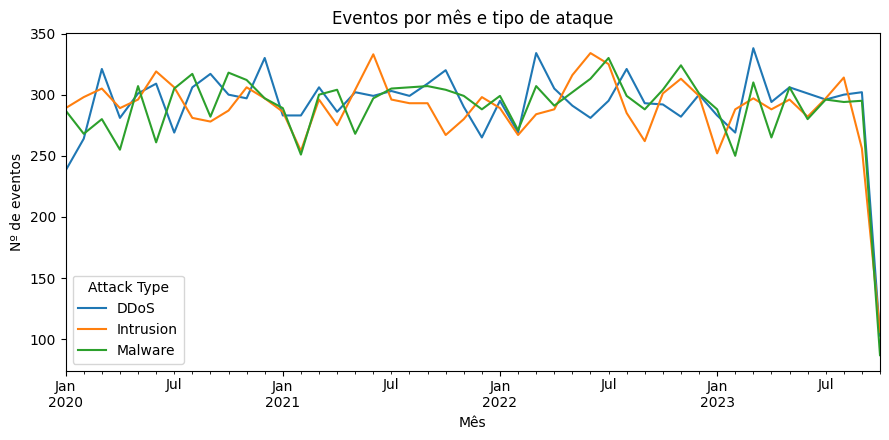

In [ ]:
# ---- Pergunta 1: tipos de ataque mais frequentes e evolução mensal ----
print(df["Attack Type"].value_counts())  # contagem total por tipo de ataque

df["ano_mes"] = df["Timestamp"].dt.to_period("M").dt.to_timestamp()  # cria uma coluna "ano-mês"
evolucao_mensal = df.groupby(["ano_mes", "Attack Type"]).size().unstack(fill_value=0)  # tabela mês x tipo

evolucao_mensal.plot(figsize=(9, 4.5), title="Eventos por mês e tipo de ataque")  # gráfico de linhas
plt.xlabel("Mês"); plt.ylabel("Nº de eventos"); plt.tight_layout(); plt.show()


In [ ]:
# ---- Pergunta 2: protocolo x tipo de ataque ----
tabela_2 = pd.crosstab(df["Attack Type"], df["Protocol"])  # tabela de contingência (cruzamento)
print(tabela_2)

chi2, p, dof, esperado = stats.chi2_contingency(tabela_2)  # teste qui-quadrado de independência
print(f"\nchi2 = {chi2:.3f} | p-valor = {p:.4f}")
print("Interpretação: p > 0,05 -> não há associação estatisticamente significativa entre as variáveis.")


Protocol     ICMP   TCP   UDP
Attack Type                  
DDoS         4508  4438  4482
Intrusion    4460  4397  4408
Malware      4461  4437  4409

chi2 = 0.321 | p-valor = 0.9884
Interpretação: p > 0,05 -> não há associação estatisticamente significativa entre as variáveis.


In [ ]:
# ---- Pergunta 3: severidade x segmento de rede, e severidade x tipo de ataque ----
tabela_3a = pd.crosstab(df["Severity Level"], df["Network Segment"])
chi2a, pa, _, _ = stats.chi2_contingency(tabela_3a)
print("Severidade x Segmento ->", f"chi2={chi2a:.3f}, p={pa:.4f}")

tabela_3b = pd.crosstab(df["Severity Level"], df["Attack Type"])
chi2b, pb, _, _ = stats.chi2_contingency(tabela_3b)
print("Severidade x Tipo de Ataque ->", f"chi2={chi2b:.3f}, p={pb:.4f}")


Severidade x Segmento -> chi2=5.315, p=0.2565
Severidade x Tipo de Ataque -> chi2=1.797, p=0.7730


In [ ]:
# ---- Pergunta 4: ação tomada x tipo de ataque ----
tabela_4 = pd.crosstab(df["Action Taken"], df["Attack Type"])
print(tabela_4)
chi2_4, p_4, _, _ = stats.chi2_contingency(tabela_4)
print(f"\nchi2 = {chi2_4:.3f} | p-valor = {p_4:.4f}")


Attack Type   DDoS  Intrusion  Malware
Action Taken                          
Blocked       4533       4553     4443
Ignored       4459       4401     4416
Logged        4436       4311     4448

chi2 = 3.488 | p-valor = 0.4797


                  count       mean        std   min     25%    50%      75%  \
Severity Level                                                                
High            13382.0  50.299650  28.859796  0.01  25.280  50.61  75.3575   
Low             13183.0  50.235696  28.800334  0.01  25.565  50.30  75.2150   
Medium          13435.0  49.808101  28.899285  0.00  24.610  50.16  74.5000   

                   max  
Severity Level          
High             99.99  
Low             100.00  
Medium           99.99  

ANOVA: F = 1.1493 | p-valor = 0.3169


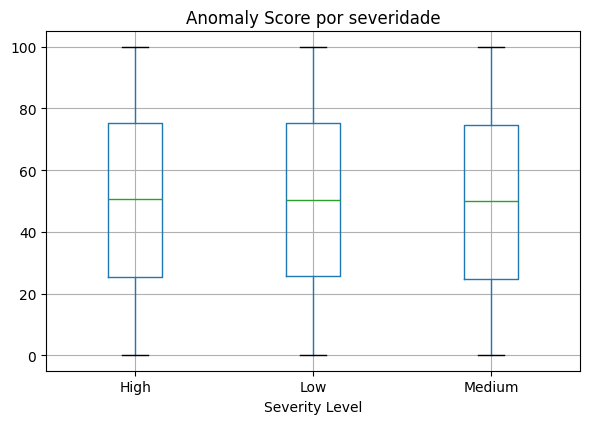

In [ ]:
# ---- Pergunta 5: Anomaly Score é maior para severidade alta? ----
resumo_5 = df.groupby("Severity Level")["Anomaly Scores"].describe()  # média, desvio, min, max por grupo
print(resumo_5)

# ANOVA de um fator: testa se as médias dos 3 grupos de severidade são estatisticamente diferentes
grupos = [grupo["Anomaly Scores"].values for _, grupo in df.groupby("Severity Level")]
f_stat, p_5 = stats.f_oneway(*grupos)
print(f"\nANOVA: F = {f_stat:.4f} | p-valor = {p_5:.4f}")

df.boxplot(column="Anomaly Scores", by="Severity Level", figsize=(6, 4.5))  # boxplot comparativo
plt.title("Anomaly Score por severidade"); plt.suptitle(""); plt.tight_layout(); plt.show()


estado
Manipur              1498
Uttar Pradesh        1485
Gujarat              1483
Maharashtra          1474
Arunachal Pradesh    1472
Karnataka            1467
West Bengal          1465
Bihar                1462
Rajasthan            1460
Uttarakhand          1441
Name: count, dtype: int64


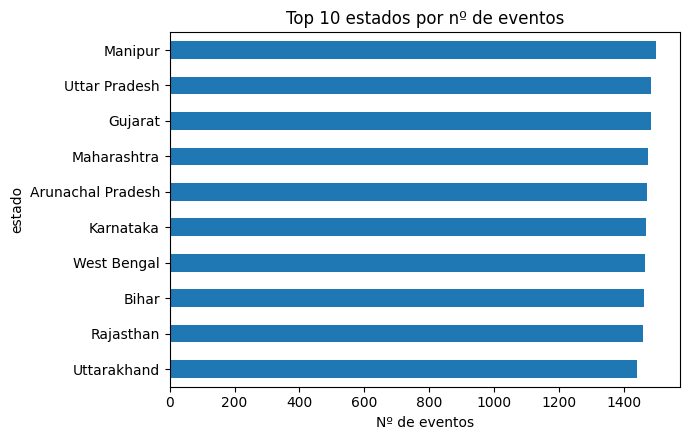

In [ ]:
# ---- Pergunta 6: concentração geográfica por tipo de ataque ----
top_estados = df["estado"].value_counts().head(10)  # 10 estados com mais eventos registrados
print(top_estados)

top_estados.sort_values().plot(kind="barh", figsize=(7, 4.5), title="Top 10 estados por nº de eventos")
plt.xlabel("Nº de eventos"); plt.tight_layout(); plt.show()


## 9. Discussão geral

Em todas as seis perguntas, os testes estatísticos (qui-quadrado e ANOVA) devem indicar
**ausência de associação significativa** (p-valor bem acima de 0,05). Isso é coerente com a
natureza da base: o fornecedor (Incribo, no Kaggle) descreve o conjunto como **sintético**, um
"playground" para prática de pipeline — não uma amostra de incidentes reais. O valor deste MVP
está na construção do pipeline e do modelo dimensional, reaplicáveis sem alteração estrutural a
uma base real de eventos de segurança, onde as mesmas perguntas tenderiam a produzir sinal
estatístico genuíno.

## Autoavaliação
*(Personalize com sua experiência real de execução no Colab/BigQuery: dificuldades, tempo de
execução, o que você mudaria, e próximos passos para uma solução de uso contínuo.)*
